In [56]:
import sys
!{sys.executable} -m pip install evidently --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Evidently pour la détection de drift
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, DataQualityPreset
    from evidently.metrics import (
        DatasetDriftMetric,
        ColumnDriftMetric,
        DatasetMissingValuesMetric
    )
    EVIDENTLY_AVAILABLE = True
except ImportError as e:
    print("Installation: !pip install evidently")
    EVIDENTLY_AVAILABLE = False

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

Installation: !pip install evidently


'c:\Users\admin\OneDrive' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


## 1. Chargement des données

In [57]:
reference_data_path = "../data/application_train.csv"
production_data_path = "../data/application_test.csv"  # Simulant les données de production

reference_data = pd.read_csv(reference_data_path)
print(f"Shape: {reference_data.shape}")

production_data = pd.read_csv(production_data_path)
print(f"Shape: {production_data.shape}")

reference_data.head()

Shape: (307511, 122)
Shape: (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Préparation des données pour l'analyse de drift

In [58]:
common_columns = [col for col in production_data.columns if col in reference_data.columns]
print(f"Nombre de colonnes communes: {len(common_columns)}")

SAMPLE_SIZE = 10000
ref_sample = reference_data[common_columns].sample(n=min(SAMPLE_SIZE, len(reference_data)), random_state=42)
prod_sample = production_data[common_columns].sample(n=min(SAMPLE_SIZE, len(production_data)), random_state=42)

print(f"\nÉchantillon de référence: {ref_sample.shape}")
print(f"Échantillon de production: {prod_sample.shape}")

Nombre de colonnes communes: 121

Échantillon de référence: (10000, 121)
Échantillon de production: (10000, 121)


## 3. Analyse descriptive comparative

In [59]:
numeric_features = ref_sample.select_dtypes(include=[np.number]).columns.tolist()
important_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
    'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

available_features = [f for f in important_features if f in numeric_features]

# Comparaison des statistiques descriptives
comparison_stats = pd.DataFrame()
for feature in available_features:
    comparison_stats[feature] = [
        ref_sample[feature].mean(),
        prod_sample[feature].mean(),
        ref_sample[feature].std(),
        prod_sample[feature].std(),
        ref_sample[feature].median(),
        prod_sample[feature].median()
    ]

comparison_stats.index = ['Ref Mean', 'Prod Mean', 'Ref Std', 'Prod Std', 'Ref Median', 'Prod Median']
print(comparison_stats.T)

                       Ref Mean      Prod Mean       Ref Std       Prod Std  \
AMT_INCOME_TOTAL  180554.015700  179223.799050  1.172164e+06  100911.972220   
AMT_CREDIT        601382.803050  516646.125900  4.059959e+05  362625.386441   
AMT_ANNUITY        27130.175068   29388.810705  1.452533e+04   15892.922053   
AMT_GOODS_PRICE   540239.346566  462466.971450  3.719097e+05  335058.868300   
DAYS_BIRTH        -16048.004500  -16085.905700  4.383076e+03    4271.188598   
DAYS_EMPLOYED      62648.627000   67070.327500  1.403044e+05  144011.693017   
EXT_SOURCE_1           0.504099       0.501588  2.110856e-01       0.205879   
EXT_SOURCE_2           0.513931       0.514388  1.918766e-01       0.183070   
EXT_SOURCE_3           0.508004       0.496491  1.963950e-01       0.188891   

                     Ref Median    Prod Median  
AMT_INCOME_TOTAL  148500.000000  157500.000000  
AMT_CREDIT        512721.000000  450000.000000  
AMT_ANNUITY        25024.500000   26248.500000  
AMT_GOODS_PRI

## 4. Calcul des indicateurs de drift manuels

In [60]:
# Calcul du drift relatif pour chaque feature
drift_indicators = {}

for feature in available_features:
    ref_mean = ref_sample[feature].mean()
    prod_mean = prod_sample[feature].mean()
    ref_std = ref_sample[feature].std()
    prod_std = prod_sample[feature].std()
    
    # Drift de la moyenne (en %)
    if ref_mean != 0:
        mean_drift_pct = abs((prod_mean - ref_mean) / ref_mean) * 100
    else:
        mean_drift_pct = 0
    
    # Drift de l'écart-type (en %)
    if ref_std != 0:
        std_drift_pct = abs((prod_std - ref_std) / ref_std) * 100
    else:
        std_drift_pct = 0
    
    drift_indicators[feature] = {
        'mean_drift_pct': mean_drift_pct,
        'std_drift_pct': std_drift_pct,
        'drift_detected': mean_drift_pct > 10  # Seuil: 10%
    }

# Affichage des résultats
drift_df = pd.DataFrame(drift_indicators).T
drift_df = drift_df.sort_values('mean_drift_pct', ascending=False)

print(drift_df)

# Comptage des features avec drift
n_drifted = drift_df['drift_detected'].sum()
print(f"Features avec drift détecté (>10%): {n_drifted}/{len(available_features)}")

                 mean_drift_pct std_drift_pct drift_detected
AMT_GOODS_PRICE       14.395911      9.908536           True
AMT_CREDIT            14.090306     10.682505           True
AMT_ANNUITY            8.325179      9.415206          False
DAYS_EMPLOYED          7.057937      2.642322          False
EXT_SOURCE_3           2.266261      3.821014          False
AMT_INCOME_TOTAL       0.736742     91.390965          False
EXT_SOURCE_1            0.49803      2.466684          False
DAYS_BIRTH             0.236174      2.552706          False
EXT_SOURCE_2           0.089023      4.589582          False
Features avec drift détecté (>10%): True/9


## 5. Visualisation des distributions

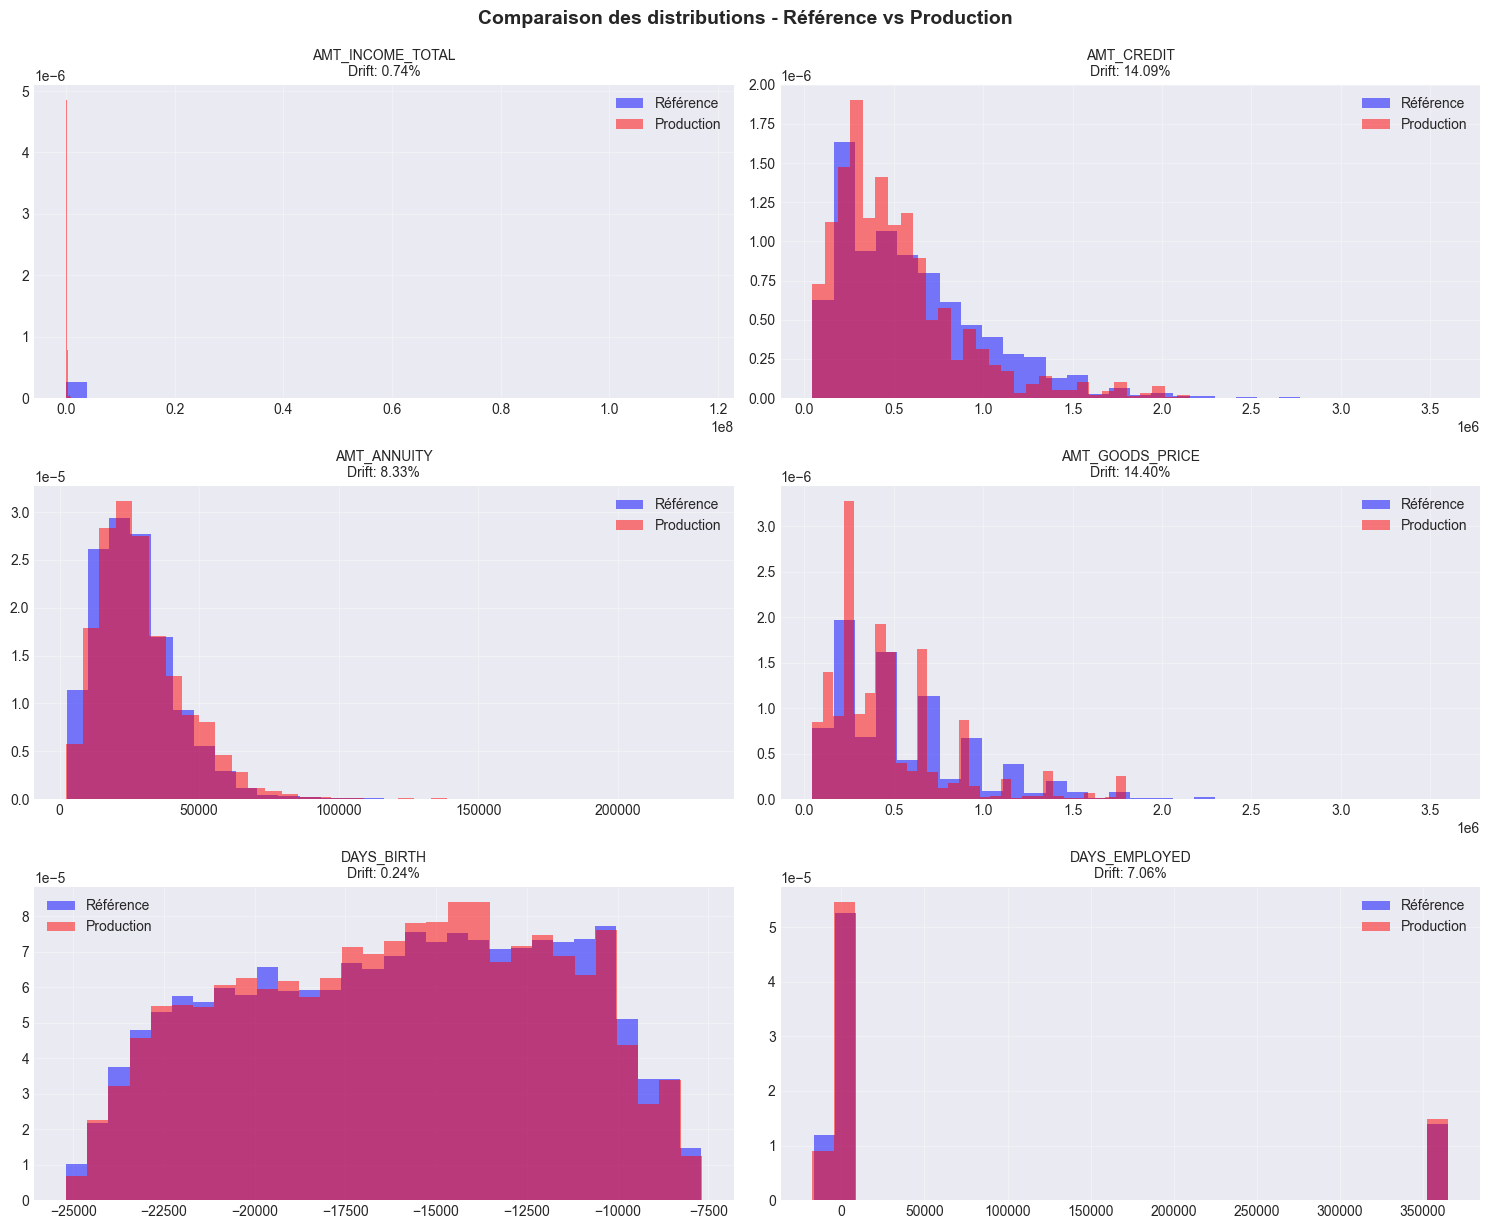

In [61]:
# Visualisation des distributions pour les features importantes
n_features = min(6, len(available_features))
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available_features[:n_features]):
    ax = axes[idx]
    
    # Histogrammes
    ref_sample[feature].hist(ax=ax, alpha=0.5, bins=30, label='Référence', color='blue', density=True)
    prod_sample[feature].hist(ax=ax, alpha=0.5, bins=30, label='Production', color='red', density=True)
    
    ax.set_title(f'{feature}\nDrift: {drift_indicators[feature]["mean_drift_pct"]:.2f}%', fontsize=10)
    ax.set_xlabel('')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Comparaison des distributions - Référence vs Production', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 6. Génération du rapport Evidently (si disponible)

In [62]:
if EVIDENTLY_AVAILABLE:

    # Création du rapport
    report = Report(metrics=[
        DataDriftPreset(),
        DataQualityPreset()
    ])
    
    report.run(
        reference_data=ref_sample,
        current_data=prod_sample
    )
    
    # Sauvegarde du rapport HTML
    report_path = "../reports/drift_report.html"
    import os
    os.makedirs("../reports", exist_ok=True)
    report.save_html(report_path)
    
    # Extraction des métriques
    report_dict = report.as_dict()
    metrics = report_dict.get("metrics", [])
    
    for metric in metrics:
        if metric.get("metric") == "DatasetDriftMetric":
            result = metric.get("result", {})
            dataset_drift = result.get("dataset_drift", False)
            n_drifted = result.get("number_of_drifted_columns", 0)
            n_columns = result.get("number_of_columns", 0)
            drift_share = result.get("share_of_drifted_columns", 0)
            

            print(f"Drift détecté: {dataset_drift}")
            print(f"Colonnes avec drift: {n_drifted}/{n_columns} ({drift_share*100:.2f}%)")
            
            if dataset_drift:
                print("ALERTE: Un drift significatif a été détecté dans le dataset!")
            else:
                print("Aucun drift significatif détecté au niveau du dataset.")
else:
    print("Evidently n'est pas disponible. Installez-le avec: pip install evidently")

Evidently n'est pas disponible. Installez-le avec: pip install evidently


## 7. Analyse des features catégorielles

In [63]:
# Features catégorielles importantes
categorical_features = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 
    'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'
]

# Filtrer les features disponibles
available_cat_features = [f for f in categorical_features if f in common_columns]

for feature in available_cat_features:
    print(f"\n{feature}:")
    
    ref_dist = ref_sample[feature].value_counts(normalize=True) * 100
    prod_dist = prod_sample[feature].value_counts(normalize=True) * 100
    
    comparison = pd.DataFrame({
        'Référence (%)': ref_dist,
        'Production (%)': prod_dist
    }).fillna(0)
    
    comparison['Diff (%)'] = comparison['Production (%)'] - comparison['Référence (%)']
    print(comparison)


NAME_CONTRACT_TYPE:
                    Référence (%)  Production (%)  Diff (%)
NAME_CONTRACT_TYPE                                         
Cash loans                  90.65           99.29      8.64
Revolving loans              9.35            0.71     -8.64

CODE_GENDER:
             Référence (%)  Production (%)  Diff (%)
CODE_GENDER                                         
F                    66.38           66.93      0.55
M                    33.62           33.07     -0.55

FLAG_OWN_CAR:
              Référence (%)  Production (%)  Diff (%)
FLAG_OWN_CAR                                         
N                     66.05           66.04     -0.01
Y                     33.95           33.96      0.01

FLAG_OWN_REALTY:
                 Référence (%)  Production (%)  Diff (%)
FLAG_OWN_REALTY                                         
Y                        67.93           69.77      1.84
N                        32.07           30.23     -1.84

NAME_INCOME_TYPE:
                 

## 8. Visualisation du drift catégoriel

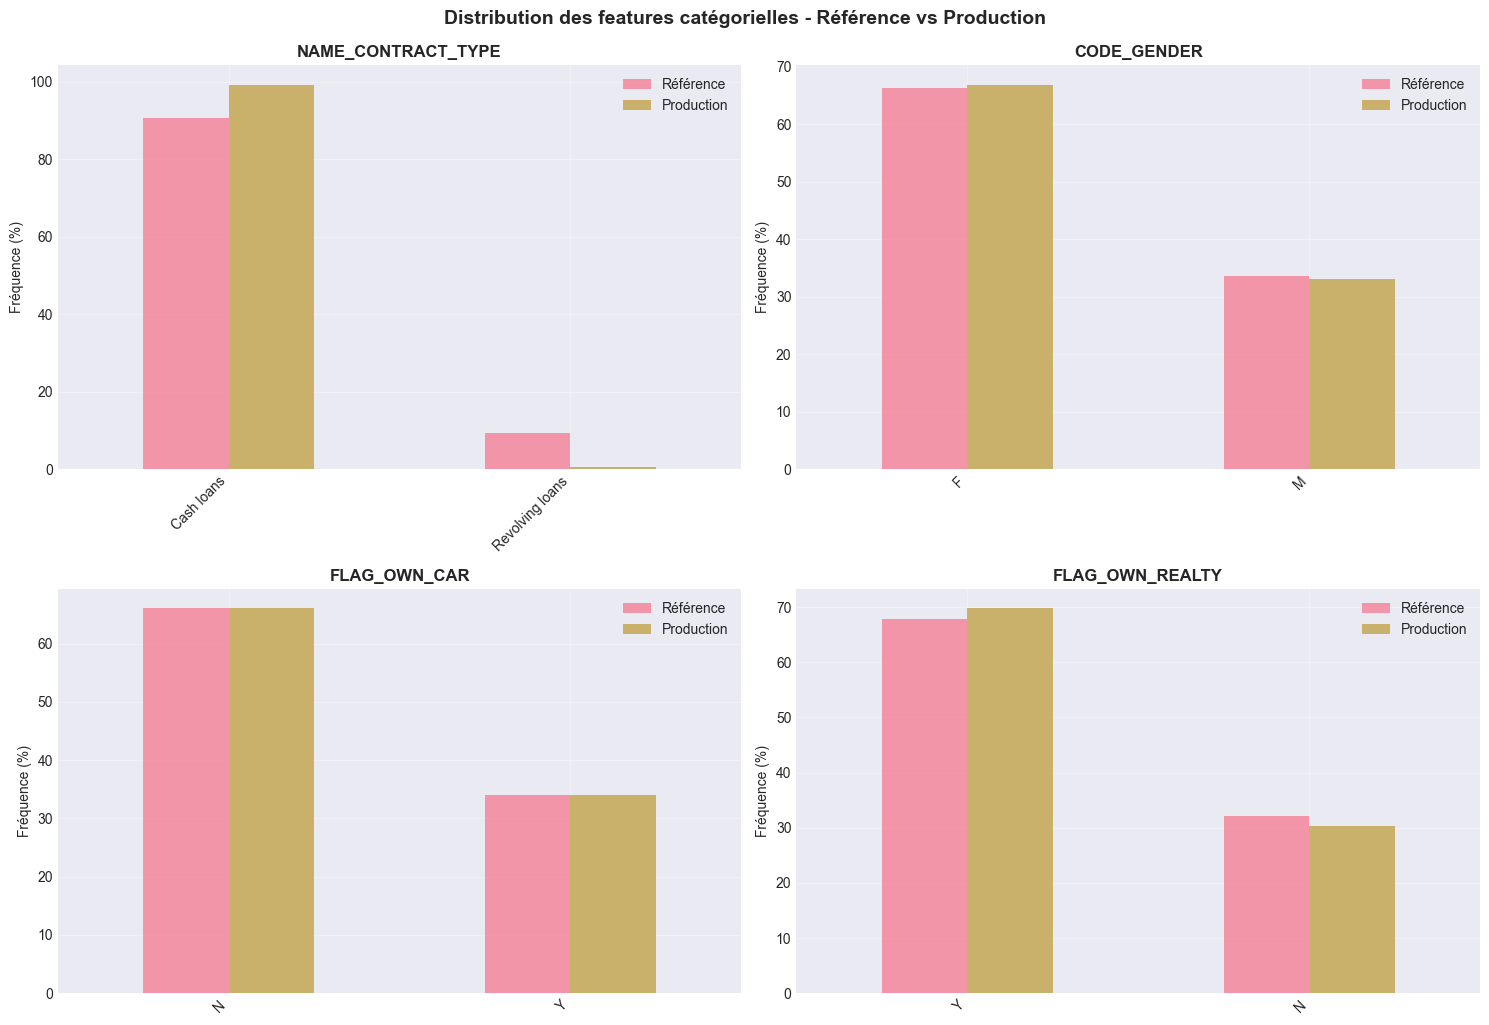

In [64]:
# Visualisation des distributions catégorielles
n_cat_features = min(4, len(available_cat_features))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(available_cat_features[:n_cat_features]):
    ax = axes[idx]
    
    ref_dist = ref_sample[feature].value_counts(normalize=True) * 100
    prod_dist = prod_sample[feature].value_counts(normalize=True) * 100
    
    comparison = pd.DataFrame({
        'Référence': ref_dist,
        'Production': prod_dist
    }).fillna(0)
    
    comparison.plot(kind='bar', ax=ax, alpha=0.7)
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_ylabel('Fréquence (%)')
    ax.set_xlabel('')
    ax.legend(['Référence', 'Production'])
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.suptitle('Distribution des features catégorielles - Référence vs Production', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 9. Résumé et recommandations

In [65]:
print(f"Données analysées:")
print(f"   - Référence: {len(ref_sample)} échantillons")
print(f"   - Production: {len(prod_sample)} échantillons")
print(f"   - Features numériques analysées: {len(available_features)}")
print(f"   - Features catégorielles analysées: {len(available_cat_features)}")


drifted_features = drift_df[drift_df['drift_detected'] == True]
print(f"Features avec drift significatif (>10%): {len(drifted_features)}")
if len(drifted_features) > 0:
    print("\nTop 3 des features avec le plus de drift:")
    for i, (feature, row) in enumerate(drifted_features.head(3).iterrows(), 1):
        print(f"   {i}. {feature}: {row['mean_drift_pct']:.2f}%")


Données analysées:
   - Référence: 10000 échantillons
   - Production: 10000 échantillons
   - Features numériques analysées: 9
   - Features catégorielles analysées: 6
Features avec drift significatif (>10%): 2

Top 3 des features avec le plus de drift:
   1. AMT_GOODS_PRICE: 14.40%
   2. AMT_CREDIT: 14.09%


## 10. Export des résultats

In [66]:
# Sauvegarde des résultats de drift
import json
import os

os.makedirs("../reports", exist_ok=True)

drift_report = {
    "timestamp": datetime.now().isoformat(),
    "n_reference_samples": len(ref_sample),
    "n_production_samples": len(prod_sample),
    "n_features_analyzed": len(available_features),
    "n_drifted_features": int(len(drifted_features)),
    "drift_threshold_pct": 10,
    "drifted_features": drifted_features['mean_drift_pct'].to_dict(),
    "all_drift_indicators": drift_df.to_dict()
}

output_path = "../reports/drift_analysis_results.json"
with open(output_path, 'w') as f:
    json.dump(drift_report, f, indent=2)


# Sauvegarde du DataFrame de drift
csv_path = "../reports/drift_indicators.csv"
drift_df.to_csv(csv_path)